<a href="https://colab.research.google.com/github/The9coder/dl-public-health-chatbot/blob/main/eda_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset download

Dataset:Symptoms to Diseases

Source:kaggle

In [2]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
from google.colab import files
files.upload()

In [4]:
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot move 'kaggle.json' to '/root/.kaggle/': Not a directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
# Download the Kaggle dataset
!kaggle datasets download -d niyarrbarman/symptom2disease

Dataset URL: https://www.kaggle.com/datasets/niyarrbarman/symptom2disease
License(s): CC0-1.0
100% 43.6k/43.6k [00:00<00:00, 49.0MB/s]



In [6]:
# Unzip the downloaded dataset
!unzip -o symptom2disease.zip

# List files to confirm extraction
!ls

Archive:  symptom2disease.zip
  inflating: Symptom2Disease.csv     
kaggle.json  sample_data  Symptom2Disease.csv  symptom2disease.zip


In [7]:
!ls

kaggle.json  sample_data  Symptom2Disease.csv  symptom2disease.zip


In [8]:
# =========================
# 1. Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Optional: download stopwords if not already
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
# =========================
# 2. Data Ingestion
# =========================
def load_dataset(path):
    df = pd.read_csv(path)   # adjust if JSON or Excel
    print("Dataset shape:", df.shape)
    print(df.head())
    return df

# Example usage
df = load_dataset("/content/Symptom2Disease.csv")


Dataset shape: (1200, 3)
   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...


In [10]:
# =========================
# 3. Preprocessing
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove punctuation/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords.words('english')]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)   # replace 'text_column' with actual column name


In [11]:
# =========================
# 4. Train/Val/Test Split
# =========================
X = df['clean_text']
y = df['label']   # replace with actual label column

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 960
Val size: 120
Test size: 120


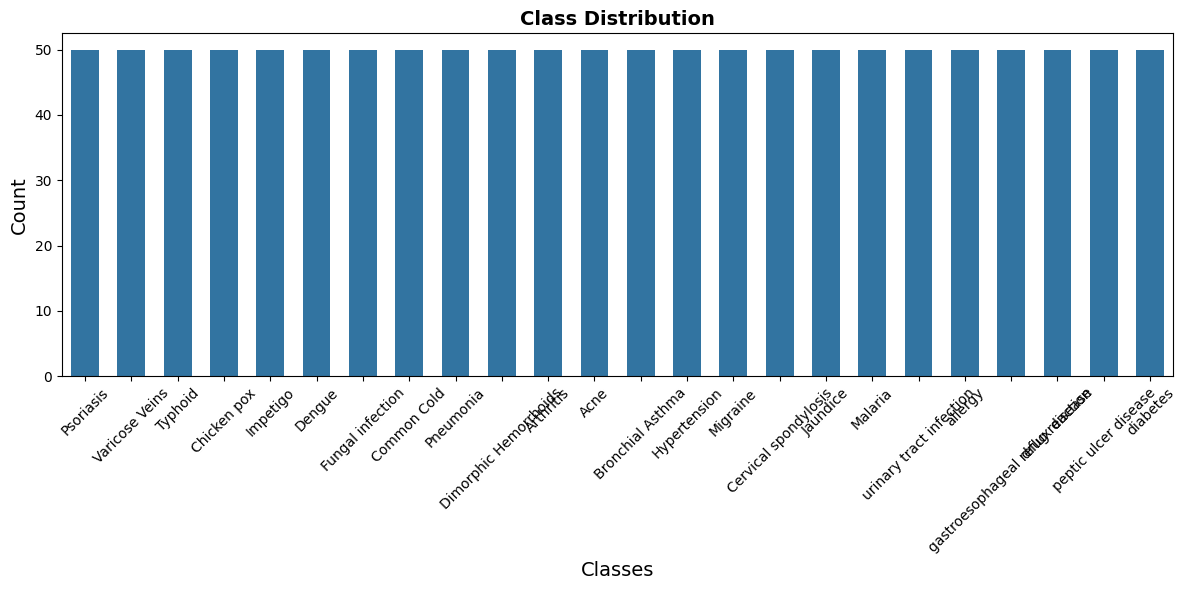

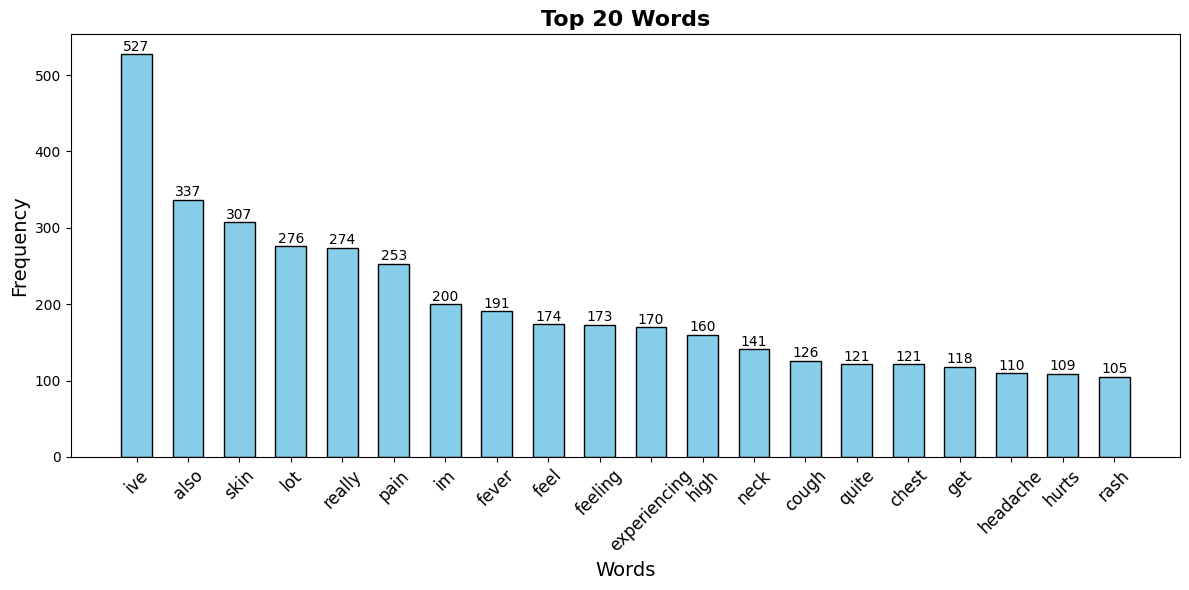

In [12]:
# =========================
# 5. Exploratory Data Analysis
# =========================
# Class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(x=y, width=0.6)
plt.title("Class Distribution", fontsize=14, weight='bold')
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)   # rotate labels if they overlap
plt.tight_layout()
plt.show()


# Word frequency visualization
from collections import Counter
all_words = "  ".join(X_train).split()
word_freq = Counter(all_words).most_common(20)

words = [w for w,_ in word_freq]
counts = [c for _,c in word_freq]

plt.figure(figsize=(12,6))
plt.bar(words, counts, width=0.6, color="skyblue", edgecolor="black")
plt.xticks(rotation=45, fontsize=12)
plt.title("Top 20 Words", fontsize=16, weight='bold')
plt.xlabel("Words", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
for i, c in enumerate(counts):
    plt.text(i, c+0.5, str(c), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 🔹 Baseline Model: TF‑IDF + Logistic Regression

After completing the EDA, we now build a simple baseline model to classify diseases based on symptoms.  
This section includes:
- Train/test split
- TF‑IDF vectorization of symptom text
- Logistic Regression classifier
- Evaluation metrics (Accuracy, Precision, Recall, F1)


In [13]:
# ✅ Baseline ML Pipeline: TF-IDF + Logistic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = df['text']   # text features
y = df['label']    # target labels

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression baseline
model = LogisticRegression(max_iter=200, solver='liblinear')
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Evaluation
print("✅ Baseline Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Baseline Model Performance
Accuracy: 0.9541666666666667

Classification Report:
                                  precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.80      0.80      0.80        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.

## 🔹 Model Experiment 1: Random Forest + Confusion Matrix

To build on the baseline Logistic Regression, we now try a Random Forest classifier.  
This section includes:
- Training a Random Forest on TF‑IDF features
- Evaluating accuracy and classification report
- Visualizing the confusion matrix for better insight


✅ Random Forest Performance
Accuracy: 0.9708333333333333

Classification Report:
                                  precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.82      0.90      0.86        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.90      0.95        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.0

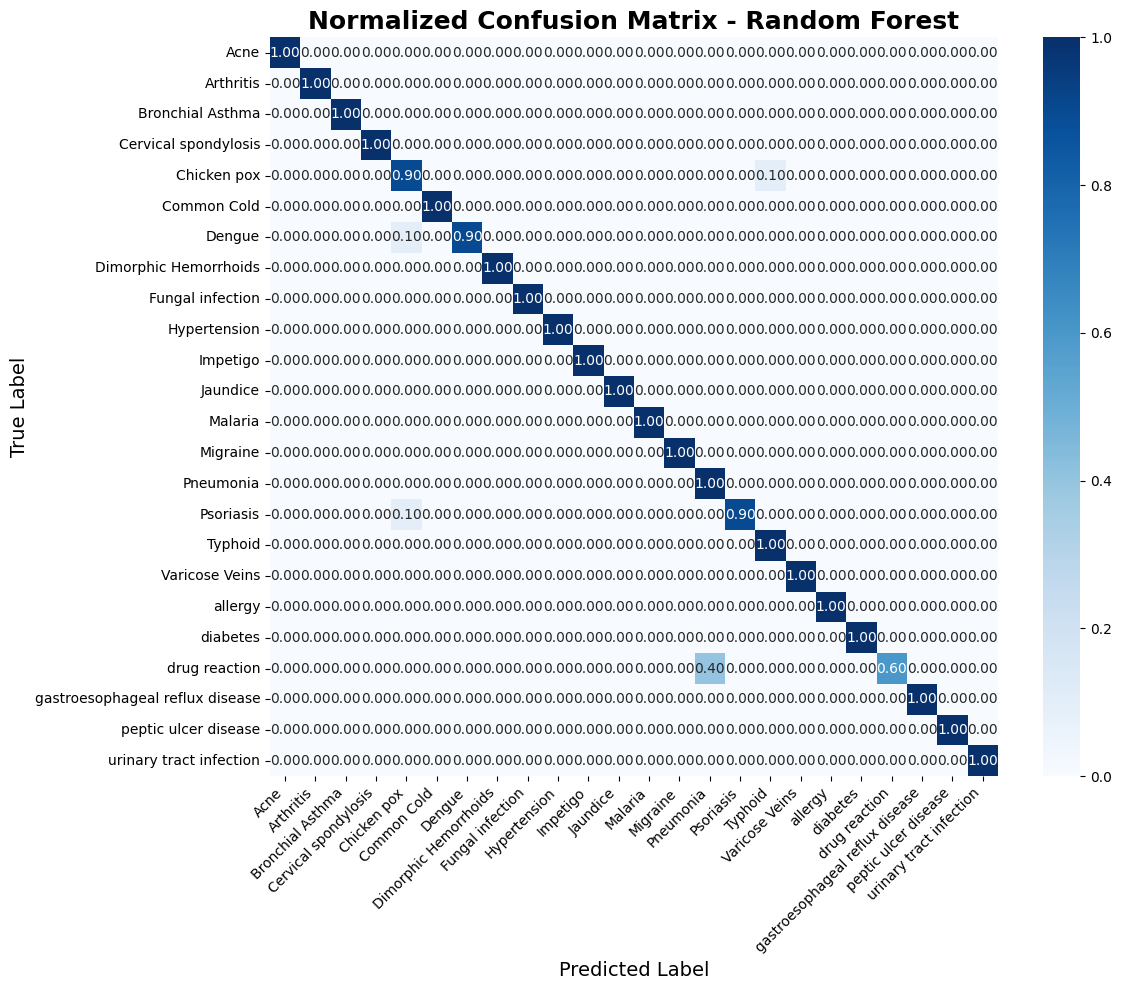

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluation
print("✅ Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


# Confusion Matrix (normalized)
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)

plt.title("Normalized Confusion Matrix - Random Forest", fontsize=18, weight='bold')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


                     Accuracy  F1 (macro)
Logistic Regression  0.954167    0.954356
Random Forest        0.970833    0.970316


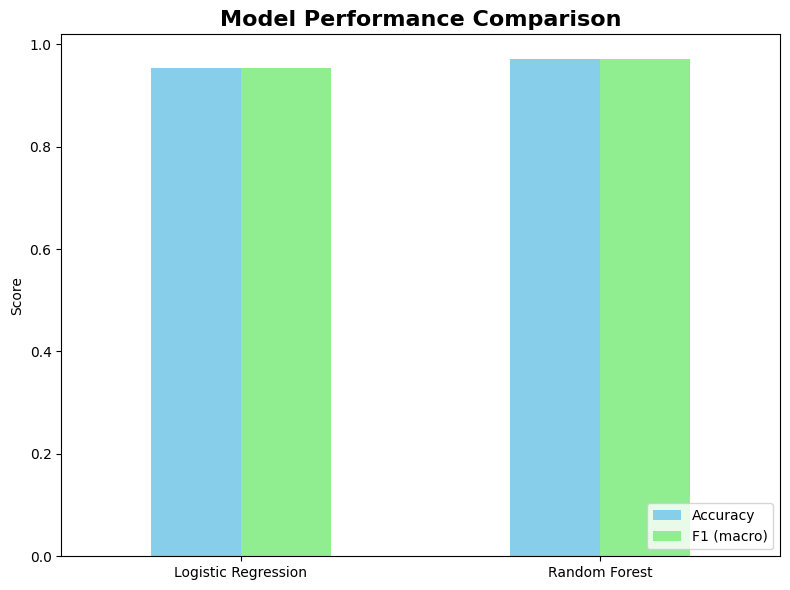

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect metrics
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": classification_report(y_test, y_pred, output_dict=True)["macro avg"]["f1-score"]
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "F1 (macro)": classification_report(y_test, y_pred_rf, output_dict=True)["macro avg"]["f1-score"]
    }
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# Display table
print(results_df)

# Bar chart comparison
results_df.plot(kind="bar", figsize=(8,6), color=["skyblue","lightgreen"])
plt.title("Model Performance Comparison", fontsize=16, weight="bold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 🔹 Model Experiment 2: Support Vector Machine (Linear Kernel)

We now test an SVM classifier with a linear kernel on the TF‑IDF features.  
This section includes:
- Training the SVM
- Evaluating accuracy and F1 score
- Confusion matrix visualization


✅ SVM Performance
Accuracy: 0.9708333333333333

Classification Report:
                                  precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.90      0.90      0.90        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.0

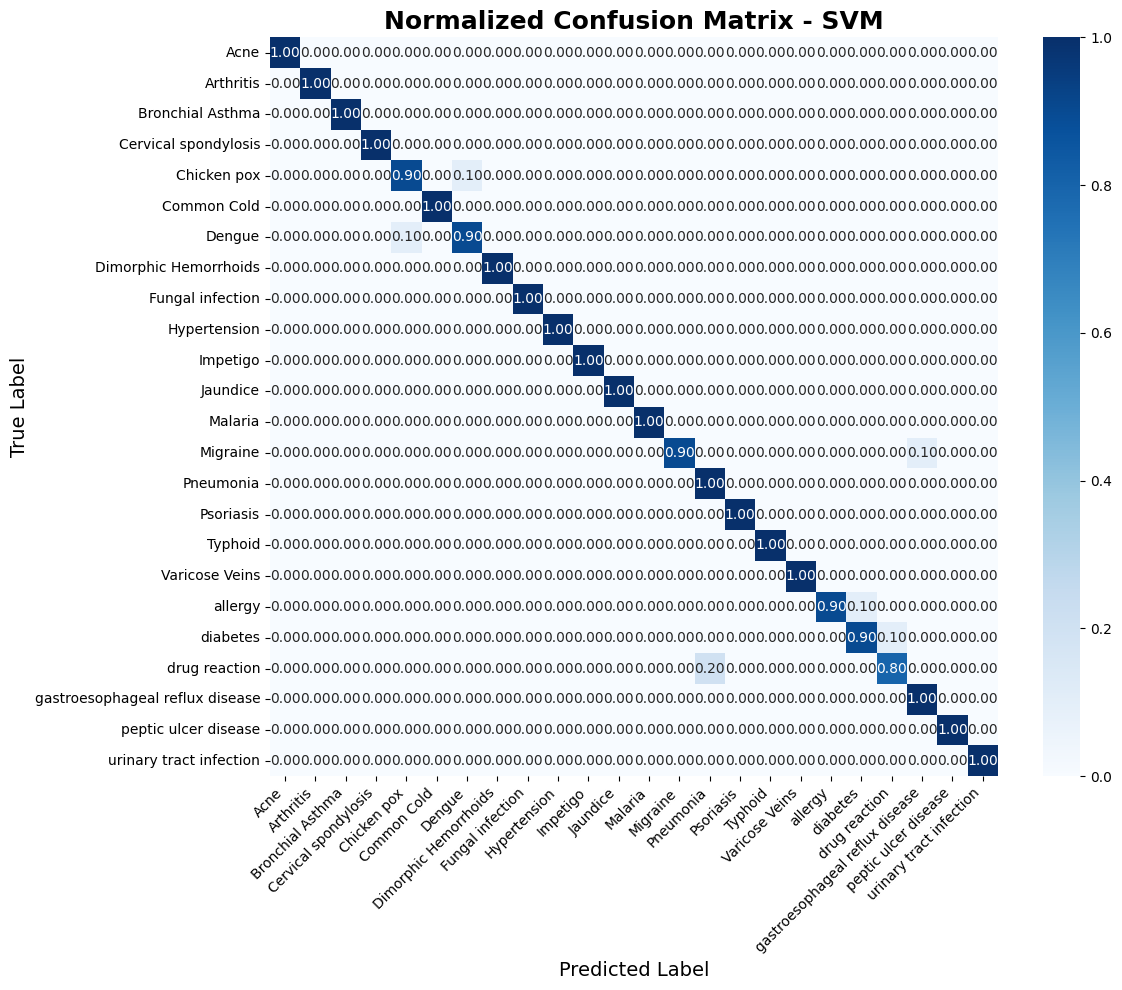

In [16]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Train SVM
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
print("✅ SVM Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix (normalized)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
cm_svm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))
sns.heatmap(cm_svm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title("Normalized Confusion Matrix - SVM", fontsize=18, weight='bold')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 🔹 Model Experiment 3: Deep Learning (Dense Neural Network)

We now build a simple feed‑forward neural network using Keras/TensorFlow.  
This section includes:
- Dense layers with ReLU activation
- Dropout for regularization
- Softmax output for multi‑class classification
- Training with categorical cross‑entropy


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(pd.factorize(y_train)[0])
y_test_cat = to_categorical(pd.factorize(y_test)[0])

# Build model
dl_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train_cat.shape[1], activation='softmax')
])

# Compile
dl_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Train
history = dl_model.fit(X_train_tfidf.toarray(), y_train_cat,
                       validation_data=(X_test_tfidf.toarray(), y_test_cat),
                       epochs=10, batch_size=32, verbose=1)

# Evaluate
loss, acc = dl_model.evaluate(X_test_tfidf.toarray(), y_test_cat, verbose=0)
print(f"✅ Deep Learning Model Accuracy: {acc:.4f}")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.2729 - loss: 3.1088 - val_accuracy: 0.0417 - val_loss: 3.1898
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6760 - loss: 2.5072 - val_accuracy: 0.0417 - val_loss: 3.4266
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9062 - loss: 1.3090 - val_accuracy: 0.0417 - val_loss: 4.4545
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9792 - loss: 0.4890 - val_accuracy: 0.0417 - val_loss: 5.8814
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9937 - loss: 0.1786 - val_accuracy: 0.0417 - val_loss: 6.8556
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9979 - loss: 0.0898 - val_accuracy: 0.0417 - val_loss: 7.5415
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9990 - loss: 0.0507 - val_accuracy: 0.0417 - val_loss: 8.0475
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.0342 - val_accuracy: 0.0417 - v

## 🔹 Model Experiment 4: Multilayer Perceptron (MLP)

We now implement a Multilayer Perceptron (MLP) using Keras/TensorFlow.  
This section includes:
- Multiple hidden dense layers
- ReLU activations
- Dropout for regularization
- Softmax output for multi‑class classification


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.2104 - loss: 3.1140 - val_accuracy: 0.4875 - val_loss: 2.8747
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5344 - loss: 2.2336 - val_accuracy: 0.8125 - val_loss: 1.3075
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8687 - loss: 0.7652 - val_accuracy: 0.9167 - val_loss: 0.3841
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9823 - loss: 0.1651 - val_accuracy: 0.9500 - val_loss: 0.1759
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9958 - loss: 0.0520 - val_accuracy: 0.9708 - val_loss: 0.1343
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 0.0249 - val_accuracy: 0.9667 - val_loss: 0.1064
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9990 - loss: 0.0162 - val_accuracy: 0.9750 - val_loss: 0.1103
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9750 - 

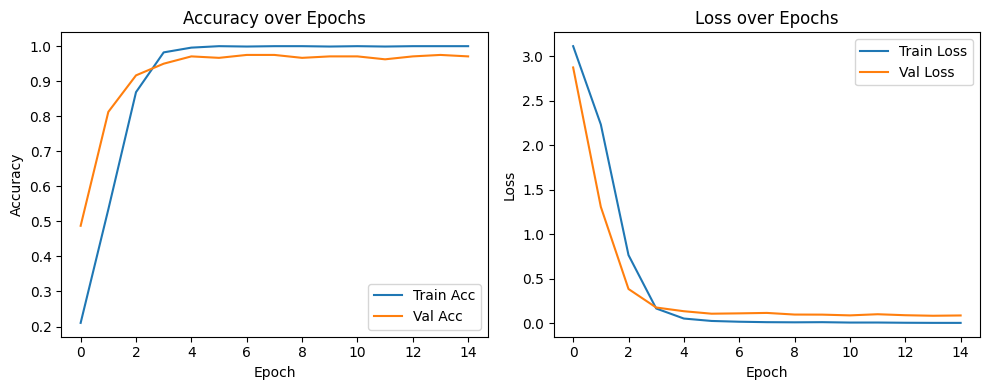

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Encode labels as integers then one-hot
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

# Build MLP model
mlp_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(y_train_cat.shape[1], activation='softmax')
])

# Compile
mlp_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train
history = mlp_model.fit(X_train_tfidf.toarray(), y_train_cat,
                        validation_data=(X_test_tfidf.toarray(), y_test_cat),
                        epochs=15, batch_size=32, verbose=1)

# Evaluate
loss, acc = mlp_model.evaluate(X_test_tfidf.toarray(), y_test_cat, verbose=0)
print(f"✅ MLP Model Accuracy: {acc:.4f}")

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [20]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# 1. Tokenize text
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_text'])
X_seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=100)

# 2. Encode labels
encoder = LabelEncoder()
y_enc = encoder.fit_transform(df['label'])   # assuming 'Disease' column has labels
y_cat = to_categorical(y_enc)

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_cat, test_size=0.2, random_state=42)

# 4. Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_cat.shape[1], activation='softmax')
])

# 5. Compile
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(X_train, y_train,
                         validation_data=(X_test, y_test),
                         epochs=15, batch_size=32,
                         callbacks=[early_stop])

# 7. Evaluate
loss, acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ LSTM Model Accuracy: {acc:.4f}")


Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step - accuracy: 0.0906 - loss: 3.1501 - val_accuracy: 0.1667 - val_loss: 3.0892
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.1437 - loss: 2.8560 - val_accuracy: 0.2542 - val_loss: 2.5750
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.3271 - loss: 2.2234 - val_accuracy: 0.5167 - val_loss: 1.7681
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.5448 - loss: 1.4932 - val_accuracy: 0.5917 - val_loss: 1.2468
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.7531 - loss: 0.8999 - val_accuracy: 0.7708 - val_loss: 0.7284
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.8562 - loss: 0.5103 - val_accuracy: 0.8625 - val_loss: 0.4826
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.9427 - loss: 0.2609 - val_accuracy: 0.8542 - val_loss: 0.4428
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.9656 - loss: 0.1859 - val_accuracy: 0.8833 - val_